Introduction


Dans ce projet, nous ne visons pas seulement à créer un modèle de détection de fraudes, mais également à optimiser sa performance pour qu'il soit efficace dans des conditions réelles. Outre l'exploration de différents algorithmes de machine learning tels que LightGBM, XGBoost et les arbres de décision, nous prévoyons d'approfondir notre compréhension du déséquilibre de classes en examinant les données sous différents angles et en identifiant les caractéristiques les plus pertinentes pour la détection de fraudes.

De plus, nous allons mettre en œuvre des techniques avancées pour gérer ce déséquilibre, telles que le suréchantillonnage de la classe minoritaire, la sous-échantillonnage de la classe majoritaire, ou encore l'utilisation de méthodes de "cost-sensitive learning" qui tiennent compte des coûts associés à chaque type d'erreur de classification.

En fin de compte, notre objectif est de développer un modèle qui soit non seulement précis dans la détection des fraudes, mais aussi robuste face à de nouvelles données et à des situations imprévues. Cela nécessitera un processus itératif de validation, d'ajustement et de perfectionnement du modèle, en gardant toujours à l'esprit l'importance de maintenir un équilibre entre la sensibilité à la fraude et la spécificité des prédictions.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/merged_df.csv', low_memory = False)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print(df)

           Num  TransactionID  isFraud  TransactionDT  TransactionAmt  \
0            0        2987000        0          86400           68.50   
1            1        2987001        0          86401           29.00   
2            2        2987002        0          86469           59.00   
3            3        2987003        0          86499           50.00   
4            4        2987004        0          86506           50.00   
...        ...            ...      ...            ...             ...   
590535  590535        3577535        0       15811047           49.00   
590536  590536        3577536        0       15811049           39.50   
590537  590537        3577537        0       15811079           30.95   
590538  590538        3577538        0       15811088          117.00   
590539  590539        3577539        0       15811131          279.95   

       ProductCD  card1  card2  card3       card4  ...                id_31  \
0              W  13926    NaN  150.0    dis

In [ ]:
df.drop(columns=['Num',], inplace=True)
print(df)

        TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  \
0             2987000        0          86400           68.50         W   
1             2987001        0          86401           29.00         W   
2             2987002        0          86469           59.00         W   
3             2987003        0          86499           50.00         W   
4             2987004        0          86506           50.00         H   
...               ...      ...            ...             ...       ...   
590535        3577535        0       15811047           49.00         W   
590536        3577536        0       15811049           39.50         W   
590537        3577537        0       15811079           30.95         W   
590538        3577538        0       15811088          117.00         W   
590539        3577539        0       15811131          279.95         W   

        card1  card2  card3       card4  card5  ...                id_31  \
0       13926    NaN  1

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB
None


A travers ce code on peut prélever les infos suivants:
*   399 colonnes est de type float
*   4 colonnes est de type int
*   31 colonnes est de type object
*   590540 lignes
*   434 colonnes (433 colonnes représente les inputs ou les features
  et unereprésente le label)

On constate que nous sommes confrontés à une très grande quantité de données.

In [ ]:
# Import the necessary module
import numpy as np

# Define the outlier_count function
def outlier_count(df):
    """
    This function returns the number of outliers in each column of a DataFrame.

    Args:
        df: A Pandas DataFrame.

    Returns:
        A dictionary containing the number of outliers for each column.
    """

    outlier_counts = {}
    for column in df.columns:
        # Check if the column data type is appropriate for outlier detection
        if not np.issubdtype(df[column].dtype, np.number):
            continue

        # Calculate the interquartile range (IQR)
        q1 = np.percentile(df[column], 25)
        q3 = np.percentile(df[column], 75)
        iqr = q3 - q1

        # Define the lower and upper bounds for outliers
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Count the number of outliers
        outlier_count = df[((df[column] < lower_bound) | (df[column] > upper_bound))].shape[0]

        # Store the outlier count in the dictionary
        outlier_counts[column] = outlier_count

    return outlier_counts

# Get the outlier counts
outlier_counts = outlier_count(df)

# Print the outlier counts
for column, count in outlier_counts.items():
    print(f"Column: {column}, Outlier Count: {count}")


Column: Num, Outlier Count: 0
Column: TransactionID, Outlier Count: 0
Column: isFraud, Outlier Count: 20663
Column: TransactionDT, Outlier Count: 0
Column: TransactionAmt, Outlier Count: 66482
Column: card1, Outlier Count: 0
Column: card2, Outlier Count: 0
Column: card3, Outlier Count: 0
Column: card5, Outlier Count: 0
Column: addr1, Outlier Count: 0
Column: addr2, Outlier Count: 0
Column: dist1, Outlier Count: 0
Column: dist2, Outlier Count: 0
Column: C1, Outlier Count: 59535
Column: C2, Outlier Count: 62214
Column: C3, Outlier Count: 2429
Column: C4, Outlier Count: 138657
Column: C5, Outlier Count: 60446
Column: C6, Outlier Count: 78329
Column: C7, Outlier Count: 67398
Column: C8, Outlier Count: 142873
Column: C9, Outlier Count: 42629
Column: C10, Outlier Count: 137098
Column: C11, Outlier Count: 74844
Column: C12, Outlier Count: 101341
Column: C13, Outlier Count: 75631
Column: C14, Outlier Count: 96090
Column: D1, Outlier Count: 0
Column: D2, Outlier Count: 0
Column: D3, Outlier Cou

In [ ]:
# Drop columns with only missing values
df.dropna(axis=1, how='all', inplace=True)

# List of dropped columns
dropped_columns = df.columns[df.isnull().all()].tolist()

# Print the list of dropped columns
print(f"Dropped columns: {dropped_columns}")


Dropped columns: []


On constate qu'aucune colonne contient uniquement des valeurs manquantes

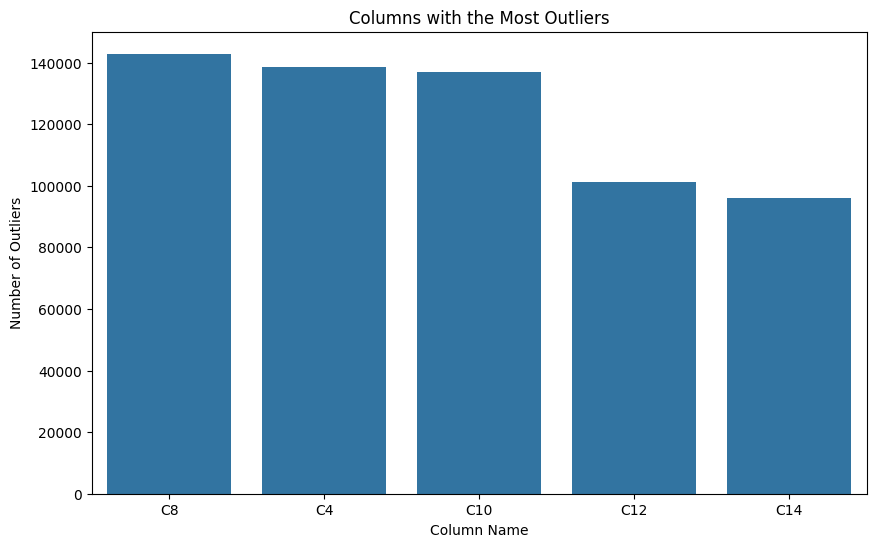

In [ ]:
# Create a dictionary to store the outlier counts for each column
outlier_counts = {}
for column in df.columns:
    # Check if the column data type is appropriate for outlier detection
    if not np.issubdtype(df[column].dtype, np.number):
        continue

    # Calculate the interquartile range (IQR)
    q1 = np.percentile(df[column], 25)
    q3 = np.percentile(df[column], 75)
    iqr = q3 - q1

    # Define the lower and upper bounds for outliers
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Count the number of outliers
    outlier_count = df[((df[column] < lower_bound) | (df[column] > upper_bound))].shape[0]

    # Store the outlier count in the dictionary
    outlier_counts[column] = outlier_count

# Get the columns with the most outliers
most_outliers_columns = sorted(outlier_counts, key=outlier_counts.get, reverse=True)[:5]

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=most_outliers_columns, y=[outlier_counts[column] for column in most_outliers_columns])
plt.xlabel("Column Name")
plt.ylabel("Number of Outliers")
plt.title("Columns with the Most Outliers")
plt.show()


Le graphique montre le nombre d'outliers, c'est-à-dire de valeurs très différentes des autres, dans différentes colonnes d'un jeu de données. Les colonnes C8 et C4 ont le plus d'outliers, tandis que les autres colonnes en ont moins. Cela signifie que dans C8 et C4, il y a plus de valeurs qui se démarquent beaucoup par rapport au reste. C'est important car ces outliers peuvent influencer les analyses qu'on fait avec ces données.

In [ ]:
missing_values = df.isnull().sum()

# Print the number of missing values in each column
for column, count in missing_values.items():
    print(f"Column: {column}, Missing Values: {count}")


Column: Num, Missing Values: 0
Column: TransactionID, Missing Values: 0
Column: isFraud, Missing Values: 0
Column: TransactionDT, Missing Values: 0
Column: TransactionAmt, Missing Values: 0
Column: ProductCD, Missing Values: 0
Column: card1, Missing Values: 0
Column: card2, Missing Values: 8933
Column: card3, Missing Values: 1565
Column: card4, Missing Values: 1577
Column: card5, Missing Values: 4259
Column: card6, Missing Values: 1571
Column: addr1, Missing Values: 65706
Column: addr2, Missing Values: 65706
Column: dist1, Missing Values: 352271
Column: dist2, Missing Values: 552913
Column: P_emaildomain, Missing Values: 94456
Column: R_emaildomain, Missing Values: 453249
Column: C1, Missing Values: 0
Column: C2, Missing Values: 0
Column: C3, Missing Values: 0
Column: C4, Missing Values: 0
Column: C5, Missing Values: 0
Column: C6, Missing Values: 0
Column: C7, Missing Values: 0
Column: C8, Missing Values: 0
Column: C9, Missing Values: 0
Column: C10, Missing Values: 0
Column: C11, Missi

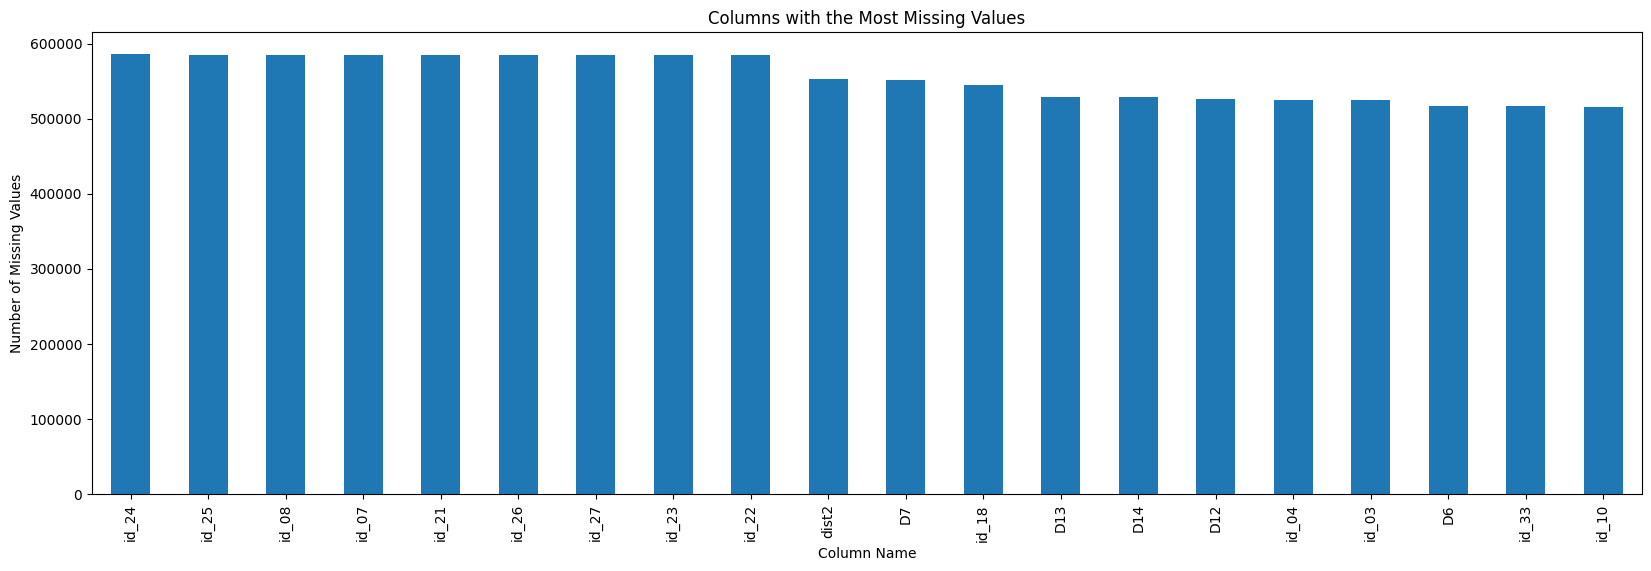

In [ ]:
# Create a bar plot of the columns with the most missing values
plt.figure(figsize=(20, 6))
missing_values.sort_values(ascending=False).head(20).plot(kind='bar')
plt.xlabel("Column Name")
plt.ylabel("Number of Missing Values")
plt.title("Columns with the Most Missing Values")
plt.show()


In [ ]:
# Identify columns with more than 90% missing values
high_missing_cols = [col for col in df.columns if df[col].isnull().sum() > (0.75 * len(df))]

# Drop the identified columns
#df.drop(high_missing_cols, axis=1, inplace=True)

# Print the list of dropped columns
print(f"Dropped columns with more than 90% missing values: {high_missing_cols}")


Dropped columns with more than 90% missing values: ['dist2', 'R_emaildomain', 'D6', 'D7', 'D8', 'D9', 'D12', 'D13', 'D14', 'V138', 'V139', 'V140', 'V141', 'V142', 'V143', 'V144', 'V145', 'V146', 'V147', 'V148', 'V149', 'V150', 'V151', 'V152', 'V153', 'V154', 'V155', 'V156', 'V157', 'V158', 'V159', 'V160', 'V161', 'V162', 'V163', 'V164', 'V165', 'V166', 'V167', 'V168', 'V169', 'V170', 'V171', 'V172', 'V173', 'V174', 'V175', 'V176', 'V177', 'V178', 'V179', 'V180', 'V181', 'V182', 'V183', 'V184', 'V185', 'V186', 'V187', 'V188', 'V189', 'V190', 'V191', 'V192', 'V193', 'V194', 'V195', 'V196', 'V197', 'V198', 'V199', 'V200', 'V201', 'V202', 'V203', 'V204', 'V205', 'V206', 'V207', 'V208', 'V209', 'V210', 'V211', 'V212', 'V213', 'V214', 'V215', 'V216', 'V217', 'V218', 'V219', 'V220', 'V221', 'V222', 'V223', 'V224', 'V225', 'V226', 'V227', 'V228', 'V229', 'V230', 'V231', 'V232', 'V233', 'V234', 'V235', 'V236', 'V237', 'V238', 'V239', 'V240', 'V241', 'V242', 'V243', 'V244', 'V245', 'V246', 'V247

In [ ]:
print(len(high_missing_cols))

208


In [ ]:
# Identify columns with more than 90% missing values
high_missing_cols = [col for col in df.columns if df[col].isnull().sum() > (0.90 * len(df))]

# Drop the identified columns
#df.drop(high_missing_cols, axis=1, inplace=True)

# Print the list of dropped columns
print(f"Dropped columns with more than 90% missing values: {high_missing_cols}")


Dropped columns with more than 90% missing values: ['dist2', 'D7', 'id_07', 'id_08', 'id_18', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27']


In [ ]:
print(len(high_missing_cols))

12


In [ ]:
df.corr()

<ipython-input-21-2f6f6606aa2c>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,id_06,id_09,id_10,id_11,id_13,id_14,id_17,id_19,id_20,id_32
TransactionID,1.000000,0.014166,0.998280,0.012025,0.010122,-0.019900,-0.010091,-0.023900,-0.000370,0.057213,...,-0.026956,-0.032954,0.009245,0.031831,0.085015,0.043151,0.222829,-0.015030,0.084105,-0.066437
isFraud,0.014166,1.000000,0.013103,0.011320,-0.013640,0.003388,0.154151,-0.033580,0.005596,-0.030387,...,-0.027139,0.029431,0.011043,0.007914,-0.019538,0.057324,0.150100,-0.041721,0.061597,0.069702
TransactionDT,0.998280,0.013103,1.000000,0.011920,0.010625,-0.019202,-0.011222,-0.024132,-0.000051,0.051972,...,-0.026329,-0.032267,0.008721,0.030883,0.086939,0.044079,0.214802,-0.011815,0.082009,-0.071392
TransactionAmt,0.012025,0.011320,0.011920,1.000000,-0.005725,0.016136,-0.109785,0.003061,-0.007421,0.028312,...,0.025777,0.008281,-0.004869,-0.040908,0.060246,-0.055490,-0.334971,0.076174,-0.105866,-0.041851
card1,0.010122,-0.013640,0.010625,-0.005725,1.000000,0.004960,0.002965,-0.093633,0.020369,-0.000060,...,0.008342,0.000651,0.005366,0.005202,0.006133,-0.013324,0.018892,0.022617,0.015917,-0.009524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
id_14,0.043151,0.057324,0.044079,-0.055490,-0.013324,-0.001115,-0.036476,-0.040165,-0.073136,-0.195392,...,-0.029647,-0.006684,-0.011014,0.017037,-0.031033,1.000000,-0.086848,-0.074575,0.358147,-0.015527
id_17,0.222829,0.150100,0.214802,-0.334971,0.018892,-0.038135,0.737195,-0.204477,-0.026830,-0.558368,...,-0.028708,-0.023937,0.038112,0.062694,-0.075997,-0.086848,1.000000,-0.214211,0.278472,0.017577
id_19,-0.015030,-0.041721,-0.011815,0.076174,0.022617,0.016537,-0.163727,0.014487,0.035769,0.043023,...,0.029647,-0.008878,-0.030461,0.004050,0.017657,-0.074575,-0.214211,1.000000,-0.088309,-0.084210
id_20,0.084105,0.061597,0.082009,-0.105866,0.015917,-0.006812,0.249036,-0.108476,-0.087289,-0.053954,...,-0.071015,-0.006150,0.018121,0.036314,-0.029427,0.358147,0.278472,-0.088309,1.000000,0.003568


In [ ]:
correlation_dict = {}

for column in df.columns:
    if column != 'isFraud' and df[column].dtype != 'object':
        correlation_dict[column] = df['isFraud'].corr(df[column].astype(float))

print(correlation_dict)


{'TransactionID': 0.014165772702318558, 'TransactionDT': 0.013103054993050249, 'TransactionAmt': 0.011319825333215242, 'card1': -0.013639969873036666, 'card2': 0.0033878791782706676, 'card3': 0.15415133308432788, 'card5': -0.03357955581230875, 'addr1': 0.005595762757557491, 'addr2': -0.030387147315388684, 'dist1': 0.021522161350321062, 'C1': 0.030569759651240924, 'C2': 0.037228939530999657, 'C3': -0.006833173826653626, 'C4': 0.030382136305078352, 'C5': -0.030753966713252937, 'C6': 0.02090898355378469, 'C7': 0.028160291640635843, 'C8': 0.03213871315829292, 'C9': -0.03170341586419489, 'C10': 0.028395987456790863, 'C11': 0.027483734598876285, 'C12': 0.031905281711225794, 'C13': -0.011145752229048657, 'C14': 0.00792055869060809, 'D1': -0.06719305903571028, 'D2': -0.08358321970827089, 'D3': -0.04627138134885129, 'D4': -0.06721630255951212, 'D5': -0.06463762954147699, 'D6': -0.0572355790334387, 'D8': -0.14263641015850023, 'D9': -0.04425253921102916, 'D10': -0.07200190861826147, 'D11': -0.045

In [ ]:
sorted_cols = sorted([key for key, value in correlation_dict.items() if abs(value) > 0.6], key=lambda x: correlation_dict[x], reverse=True)
print(sorted_cols)


[]


On remarque qu'il y a aucune relation lineaire entre la colonne 'isFraud' et les autres colonnes vu que la liste est vide.

In [ ]:
fraud_count = df['isFraud'].value_counts()
print(f"Number of non-fraudulent transactions: {fraud_count[0]}")
print(f"Number of fraudulent transactions: {fraud_count[1]}")

Number of non-fraudulent transactions: 569877
Number of fraudulent transactions: 20663


Il est observé qu'il y a deux classes dans les données : une classe majoritaire représentant les transactions non frauduleuses et une classe minoritaire représentant les transactions frauduleuses. Cette disparité entre les deux classes conduit à un problème de déséquilibre de classes, où la classe frauduleuse est sous-représentée par rapport à la classe non frauduleuse. Ce déséquilibre peut poser des défis lors de la modélisation et de l'analyse des données, car les modèles peuvent avoir tendance à privilégier la classe majoritaire, conduisant à des performances sous-optimales dans la détection des fraudes.

<ipython-input-6-e6801e96763f>:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df, x='isFraud', bins=2, palette='viridis')


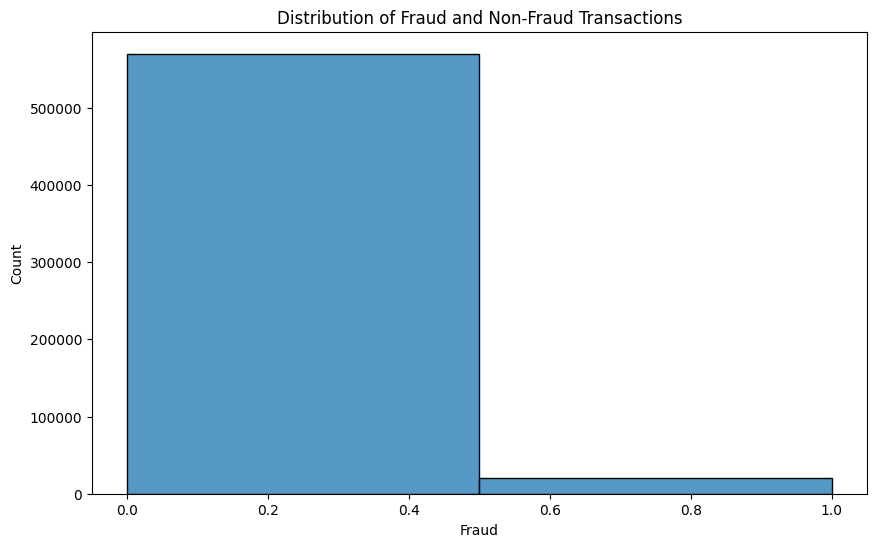

In [ ]:
# Create the histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='isFraud', bins=2, palette='viridis')

# Add labels and title
plt.xlabel('Fraud')
plt.ylabel('Count')
plt.title('Distribution of Fraud and Non-Fraud Transactions')

# Show the plot
plt.show()


In [ ]:
df.describe()

,Num,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,590540.000000,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,...,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,295269.500000,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,...,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,170474.358321,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,...,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,0.000000,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,10.000000,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,147634.750000,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,295269.500000,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,...,166.000000,15.000000,341.000000,472.000000,252.000000,14.000000,11.000000,321.000000,149.000000,24.000000
75%,442904.250000,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,...,225.000000,15.000000,427.000000,533.000000,486.500000,14.000000,15.000000,371.000000,169.000000,32.000000
max,590539.000000,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,...,229.000000,29.000000,671.000000,661.000000,854.000000,44.000000,26.000000,548.000000,216.000000,32.000000


Ces statistiques fournissent une vue d'ensemble des données numériques, telles que les transactions, les cartes de crédit utilisées, etc., permettant ainsi d'analyser la distribution et la dispersion des valeurs dans chaque colonne.